# Customer Churn Classification (Random Forest)

Crystal Ford | GitHub: github.com/crystalmford

## Executive Summary

In this project, I built a machine learning model to predict which customers were most likely to cancel their service. The goal was to help the business identify at-risk customers and take action before they left.

I cleaned and encoded a dataset with more than 700 features, trained a Random Forest classifier, and tuned the model using GridSearchCV.

### Final Model Performance
- Accuracy: 87.8%
- Precision: 86.3%
- Recall: 63.9%
- F1 Score: 73.5%
- AUC-ROC: 95.1%

The final model performed well and could be used to support retention efforts such as targeted offers, proactive outreach, or additional customer support.

---

## Business Problem

The goal of this project was to figure out which customers were most likely to cancel their service.

If a company knows who is thinking about leaving, they can reach out before it happens. That might mean offering a discount, checking in to see if there is a problem, or providing extra support.

In short, I wanted to build a model that could spot customers who were at high risk of leaving so the company could take action to keep them.

---

## Why I Chose Random Forest

I chose a Random Forest classifier because it works well with large datasets and can handle many different types of variables.

Random Forest builds many decision trees and combines their predictions. This usually produces more reliable results than using a single decision tree.

I chose this method because:
- The dataset contained more than 700 features after encoding.
- The data included binary, categorical, and continuous variables.
- Random Forest often performs well without a lot of extra feature engineering.


---

## Tools Used

- Python
- pandas
- NumPy
- scikit-learn
- Matplotlib
- Seaborn

---

## Data Preparation

The original dataset included numeric, categorical, and yes/no variables.

To prepare the data for modeling, I:

1. Removed columns that were not useful for prediction, such as IDs and geographic details.
2. Converted yes/no fields to binary values (1 and 0).
3. Applied one-hot encoding to categorical variables such as contract type and payment method.
4. Verified that all features were numeric.
5. Saved the cleaned dataset as `churn_cleaned.csv`.

After preprocessing, the final dataset contained more than 700 model-ready features.

### Example Feature Types

**Binary Variables**
- Churn (target)
- Techie
- Phone
- Tablet
- OnlineSecurity
- StreamingTV
- PaperlessBilling

**Continuous Variables**
- MonthlyCharge
- Tenure
- Age
- Income
- Outage_sec_perweek

**Categorical Variables (One-Hot Encoded)**
- Contract
- InternetService
- PaymentMethod
- Job
- Gender
- Dependents

## Data Preparation

Before training the model, I cleaned the dataset and converted all variables into a numeric format that could be used for machine learning.

This included:
- Removing columns that were not useful for prediction
- Converting yes/no values to 1 and 0
- One-hot encoding categorical variables

The result was a fully numeric dataset ready for modeling.

In [6]:
from google.colab import files
uploaded = files.upload()

Saving churn_clean.csv to churn_clean.csv


In [7]:
# Data Cleaning

import pandas as pd
import numpy as np

# Load the cleaned customer churn dataset.
# This file contains the original variables before one-hot encoding.
df = pd.read_csv("churn_clean.csv")

# Remove columns that are identifiers or location details.
# These fields are useful for record-keeping but not for predicting churn.
columns_to_drop = [
    "CaseOrder",
    "Customer_id",
    "Interaction",
    "UID",
    "City",
    "State",
    "County",
    "Zip",
    "Lat",
    "Lng",
    "Population",
    "Area",
    "TimeZone",
    "Job"
]

df.drop(columns=columns_to_drop, inplace=True)

# Convert Yes/No fields to 1 and 0 so they can be used by the model.
binary_map = {"Yes": 1, "No": 0}

binary_columns = [
    "Techie",
    "Port_modem",
    "Tablet",
    "Phone",
    "Multiple",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling",
    "Churn"
]

df[binary_columns] = df[binary_columns].replace(binary_map)

# Find the remaining text columns and convert them to one-hot encoded features.
# This turns categories such as contract type and payment method into numeric columns.
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=False
)

# Verify that all columns are numeric and ready for modeling.
assert df.select_dtypes(include=["object"]).empty, \
    "Non-numeric columns still exist."

# Save the cleaned dataset for the modeling steps.
df.to_csv("churn_cleaned.csv", index=False)

print("Cleaned and encoded dataset saved.")
print(f"Final dataset shape: {df.shape}")

Cleaned and encoded dataset saved.
Final dataset shape: (10000, 48)


/tmp/ipykernel_4895/878743945.py:50: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_columns] = df[binary_columns].replace(binary_map)


## Train / Validation / Test Split

After cleaning the data, I split it into three separate datasets.

- **Training Set (60%)** – used to train the model
- **Validation Set (20%)** – used to evaluate the first version of the model and tune its settings
- **Test Set (20%)** – used for the final performance check

I used stratified sampling to make sure each dataset had about the same mix of customers who stayed and customers who left.

For example, if 25% of customers in the original dataset canceled their service, then about 25% of the customers in each split also canceled.

This helps ensure that each dataset is a fair representation of the original data and makes the evaluation results more reliable.

In [8]:
# Split the Data into Training, Validation, and Test Sets

from sklearn.model_selection import train_test_split

# Load the cleaned dataset
df_clean = pd.read_csv("churn_cleaned.csv")

# Separate the input features (X) from the target variable (y).
# X contains all columns except Churn.
# y contains the Churn column we want to predict.
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

# First split:
# - 60% of the data goes to the training set.
# - 40% is temporarily held aside for validation and testing.
#
# stratify=y keeps the same overall mix of churners and non-churners
# in each dataset.
# random_state=42 makes the split reproducible.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

# Second split:
# Split the temporary 40% into two equal parts:
# - 20% validation
# - 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Optional: Save each dataset to CSV for inspection or reuse.
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)

X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)

X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Train, validation, and test sets saved.")
print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

Train, validation, and test sets saved.
Training set:   (6000, 47)
Validation set: (2000, 47)
Test set:       (2000, 47)


## Baseline Model

I started by training a Random Forest model using the default settings in scikit-learn.

This gave me a solid starting point and allowed me to see how well the model performed before adjusting any of its settings.

### Validation Set Performance

- Accuracy: 88.6%
- Precision: 88.3%
- Recall: 65.5%
- F1 Score: 75.2%
- AUC-ROC: 95.7%

### What These Results Mean

The baseline model performed well.

When the model predicted that a customer would leave, it was usually correct. It also identified about two-thirds of the customers who actually churned.

The AUC-ROC score of 95.7% was especially encouraging. This means the model was very good at separating customers who were likely to leave from those who were likely to stay.

Overall, the baseline model gave me a strong starting point before tuning the hyperparameters.

Validation Accuracy:  0.9030
Validation Precision: 0.8500
Validation Recall:    0.7698
Validation F1 Score:  0.8079
Validation AUC-ROC:   0.9601


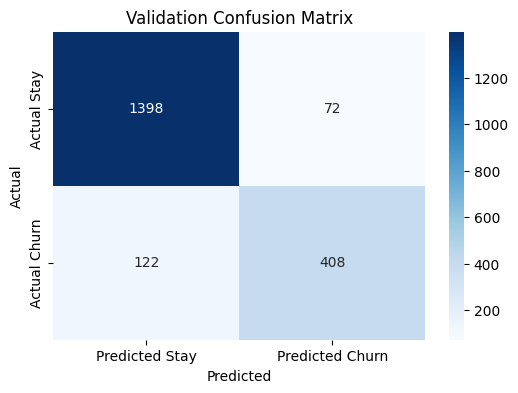

In [12]:
# Baseline Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a baseline Random Forest model using the default settings.
# random_state=42 ensures the results are reproducible.
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the training data.
rf_model.fit(X_train, y_train)

# Generate predictions for the validation set.
y_val_pred = rf_model.predict(X_val)

# Generate predicted probabilities.
# We use these probabilities to calculate AUC-ROC.
y_val_proba = rf_model.predict_proba(X_val)[:, 1]

# Calculate evaluation metrics.
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)

# Print the validation results.
print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1 Score:  {val_f1:.4f}")
print(f"Validation AUC-ROC:   {val_auc:.4f}")

# Create a confusion matrix to visualize the predictions.
cm = confusion_matrix(y_val, y_val_pred)

# Plot the confusion matrix.
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Stay", "Predicted Churn"],
    yticklabels=["Actual Stay", "Actual Churn"]
)

plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Hyperparameter Tuning

After training the baseline model, I used GridSearchCV to test different combinations of Random Forest settings and automatically select the model with the best F1 score.

The goal was to see whether changing the model settings could improve performance, especially the F1 score.

I focused on the F1 score because it balances two important goals:

- Finding customers who are likely to leave
- Avoiding too many false alarms

The grid search tested different values for:

- Number of trees
- Maximum tree depth
- Minimum samples needed to split a node
- Minimum samples needed at a leaf
- Number of features considered at each split

In total, GridSearchCV tested 48 combinations using 5-fold cross-validation.

The best-performing model used the following settings:

```python
{
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 200
}

In [13]:
# Hyperparameter Tuning with GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define the Random Forest settings to test.
param_grid = {
    "n_estimators": [100, 200],      # Number of trees in the forest
    "max_depth": [None, 10, 20],     # Maximum depth of each tree
    "min_samples_split": [2, 5],     # Minimum samples required to split a node
    "min_samples_leaf": [1, 2],      # Minimum samples required at a leaf node
    "max_features": ["sqrt", "log2"] # Number of features considered at each split
}

# Test every combination of these settings and keep the model
# with the highest F1 score.
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,            # 5-fold cross-validation
    scoring="f1",    # Optimize for F1 score
    n_jobs=-1,       # Use all available CPU cores
    verbose=2
)

# Train all parameter combinations on the training data.
grid_search.fit(X_train, y_train)

# Display the best-performing settings and score.
print("Best Parameters Found:")
print(grid_search.best_params_)

print("\nBest F1 Score from GridSearchCV:")
print(f"{grid_search.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters Found:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best F1 Score from GridSearchCV:
0.7778


## Final Model Performance

After tuning the model, I evaluated the best-performing version on the test set.

The test set was not used during training or tuning, so it provided an unbiased estimate of how well the model would perform on new data.

### Test Set Results

- Accuracy: 87.8%
- Precision: 86.3%
- Recall: 63.9%
- F1 Score: 73.5%
- AUC-ROC: 95.1%

### What These Results Mean

The final results were very close to the validation results, which suggests the model generalized well and was not overfitting.

The model was especially strong at ranking customers by churn risk, as shown by the AUC-ROC score of 95.1%.

Overall, the model performed well and was able to identify customers who were likely to cancel their service.

Test Accuracy: 0.8915
Test Precision: 0.8213552361396304
Test Recall: 0.7547169811320755
Test F1 Score: 0.7866273352999017
Test AUC-ROC: 0.9534084199717623


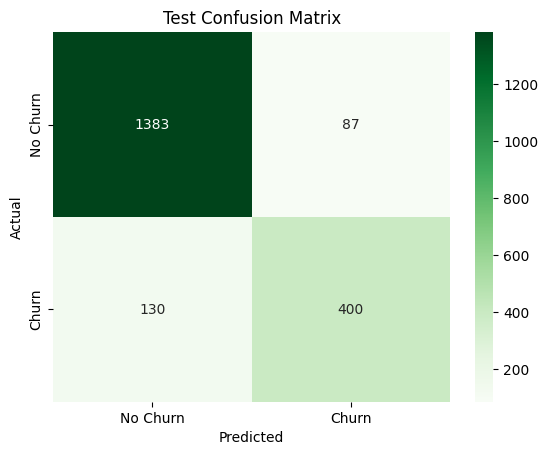

In [14]:
# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_
# Predict on the test set
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]
# Print metrics
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test Precision:", precision_score(y_test, y_test_pred))
print("Test Recall:", recall_score(y_test, y_test_pred))
print("Test F1 Score:", f1_score(y_test, y_test_pred))
print("Test AUC-ROC:", roc_auc_score(y_test, y_test_proba))
# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
xticklabels=['No Churn', 'Churn'],
yticklabels=['No Churn', 'Churn'])
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Business Takeaway

The final model performed about the same on the test set as it did on the validation set, which is a good sign. It suggests the model was stable and was not just memorizing the training data.

The model had strong precision and a high AUC-ROC score, meaning it was good at separating customers who were likely to leave from customers who were likely to stay.

In plain English: this model could help a company figure out which customers may need attention before they cancel.

That could mean reaching out with a discount, checking whether they are having service issues, or offering extra support.

---

## Limitations and Future Improvements

This model only used the data available in the original dataset. It did not include some details that could make churn easier to predict, such as:

- Customer satisfaction scores
- Support ticket history
- Recent complaints
- Recent usage patterns
- Billing issues

In a real business setting, I would also retrain the model regularly with newer data so it stays accurate as customer behavior changes.

---

## References

- scikit-learn documentation
- pandas documentation
